# Machine Learning-Based Pair Trading Strategy with Zipline and Sharadar Data
## Systematic Pair Selection using PCA, Clustering, and Statistical Tests
**Modified version without arch package - compatible with Python 3.6**

**Bug-fixed version.** Key corrections:
- Pair selection (formation) window is now 2019-2021 and the backtest is 2022-2024, so results are out-of-sample (previously the backtest fully contained the selection window)
- Universe no longer requires survival through the backtest period (survivorship bias) and is screened by median daily dollar volume, excluding warrants/preferreds
- Prices for pair selection now come from `DataPortal` (split/dividend-adjusted) instead of raw unadjusted bars
- Fixed swapped `slope, intercept` unpacking from `sm.OLS(...).params` with `prepend=True` (the backtests previously traded on a corrupted spread)
- Traded pairs no longer share symbols (`order_target_percent` targets are absolute, so shared symbols overwrote each other's positions)
- Hurst exponent uses `kind='random_walk'` (`kind='price'` breaks on a mean-zero spread)
- Half-life AR(1) regression drops the first observation instead of injecting an artificial point via `np.roll`
- Entry orders fire only on entry (not re-targeted every bar), errors are logged instead of silently swallowed, and the trading orientation matches the tested dependent/independent regression

### Step 1: Import Libraries and Load Data

In [1]:
import warnings
warnings.filterwarnings('ignore')

from fsharadar import sep
import pandas as pd
import numpy as np
from zipline import run_algorithm
from zipline.api import order_target_percent, symbol, set_commission, schedule_function
from zipline.finance.commission import PerTrade
from zipline.utils.calendars import get_calendar
import pyfolio as pf

# Machine Learning and Statistics
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import OPTICS
from itertools import combinations
from statsmodels.tsa.stattools import coint
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant
from hurst import compute_Hc
import statsmodels.api as sm

# Visualization
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

print("Libraries imported successfully")

Libraries imported successfully


### Helper Function for Cointegration Test (replaces arch.engle_granger)

In [2]:
def simple_cointegration_test(y, x):
    """
    Simple Engle-Granger cointegration test using statsmodels
    Returns: (pvalue, hedge_ratio, spread, intercept)
    """
    # Run OLS regression (add_constant prepends the constant, so
    # params order is [intercept, slope])
    model = OLS(y, add_constant(x))
    results = model.fit()
    
    # Get hedge ratio (slope) and intercept
    intercept = results.params.iloc[0]
    hedge_ratio = results.params.iloc[1]
    
    # Calculate spread
    spread = y - (hedge_ratio * x + intercept)
    
    # Use coint to get p-value
    _, pvalue, _ = coint(y, x)
    
    return pvalue, hedge_ratio, spread, intercept

print("Helper function defined")

Helper function defined


In [3]:
# Load the Sharadar bundle
bundle = sep.load()
print("Bundle loaded successfully")

Bundle loaded successfully


### Step 2: Select Universe of Assets
We'll select liquid stocks from the bundle for analysis

In [4]:
# Get all assets from the bundle
all_assets = bundle.asset_finder.retrieve_all(bundle.asset_finder.equities_sids)

# Pair-selection (formation) window: 3 years ending BEFORE the backtest starts,
# so pair selection never sees backtest data (no look-ahead bias).
# Backtest period will be 2022-01-01 to 2024-12-31.
analysis_end_date = pd.Timestamp('2021-12-31', tz='UTC')
analysis_start_date = analysis_end_date - pd.Timedelta(days=3*365)

# Select assets that have data covering the formation period.
# Requiring end_date >= analysis_end_date only uses information available at
# the END of the formation window (asset was alive then) - it does NOT require
# survival through the backtest, so there is no survivorship bias.
selected_assets = [
    asset for asset in all_assets 
    if asset.start_date <= analysis_start_date and asset.end_date >= analysis_end_date
]

# Exclude obvious non-common-stock listings: preferred shares (symbols with
# '-' or '.') and warrants/units (5-letter symbols ending in W or U).
# Heuristic, but keeps the universe to tradeable common stocks.
def is_common_stock(sym):
    if '-' in sym or '.' in sym:
        return False
    if len(sym) == 5 and sym[-1] in ('W', 'U'):
        return False
    return True

candidate_assets = [a for a in selected_assets if is_common_stock(a.symbol)]

print(f"Total assets in bundle: {len(all_assets)}")
print(f"Assets with sufficient history: {len(selected_assets)}")
print(f"Common-stock candidates: {len(candidate_assets)}")

# The final 200-asset universe is chosen in the next step by median daily
# dollar volume (a real liquidity screen, instead of just the first 200).

# Display sample candidates
print("\nSample candidates:")
for asset in candidate_assets[:10]:
    print(f"{asset.symbol}: {asset.start_date.date()} to {asset.end_date.date()}")

Total assets in bundle: 21779
Assets with sufficient history: 4693
Common-stock candidates: 4385

Sample candidates:
EVO: 2008-05-06 to 2025-06-30
FNGR: 2017-08-01 to 2025-06-30
APLD: 2002-07-22 to 2025-06-30
RSPI: 1997-12-31 to 2022-02-02
GTBP: 2018-03-27 to 2025-06-30
MAMA: 2013-05-30 to 2025-06-30
NMTC: 2018-03-15 to 2025-06-30
BRFH: 2012-04-04 to 2025-06-30
COSM: 2013-01-02 to 2025-06-30
ROII: 2010-02-16 to 2024-02-27


### Step 3: Extract Historical Prices and Calculate Returns

In [5]:
# Get historical price data via DataPortal so that split/dividend adjustments
# are applied (load_raw_arrays returns raw UNADJUSTED milli-dollar bars, which
# creates fake structural breaks at splits and distorts the tests)
from zipline.data.data_portal import DataPortal

trading_calendar = get_calendar('XNYS')
sessions = bundle.equity_daily_bar_reader.sessions
mask = (sessions >= analysis_start_date) & (sessions <= analysis_end_date)
valid_sessions = sessions[mask]

data_portal = DataPortal(
    bundle.asset_finder,
    trading_calendar=trading_calendar,
    first_trading_day=bundle.equity_daily_bar_reader.first_trading_day,
    equity_daily_reader=bundle.equity_daily_bar_reader,
    adjustment_reader=bundle.adjustment_reader,
)

def load_history(assets, field):
    df = data_portal.get_history_window(
        assets,
        valid_sessions[-1],
        len(valid_sessions),
        '1d',
        field,
        'daily',
    )
    df.columns = [a.symbol for a in df.columns]
    # Drop duplicated symbols (reused tickers) - keep first occurrence
    df = df.loc[:, ~df.columns.duplicated()]
    return df

print(f"Loading adjusted close and volume for {len(candidate_assets)} candidates...")
all_closes = load_history(candidate_assets, 'close')
all_volumes = load_history(candidate_assets, 'volume')

# Liquidity screen: keep the 200 assets with the highest median daily dollar volume
dollar_volume = (all_closes * all_volumes).median()
universe_symbols = dollar_volume.nlargest(200).index.tolist()
prices = all_closes[universe_symbols]

# Remove columns with too many NaN values
prices = prices.dropna(axis=1, thresh=len(prices)*0.95)

# Forward fill remaining NaN values
prices = prices.fillna(method='ffill').dropna(axis=1)

print(f"Price data shape: {prices.shape}")
print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"\nAssets with complete data: {len(prices.columns)}")

# Calculate daily returns
daily_returns = prices.pct_change().dropna()
print(f"\nDaily returns shape: {daily_returns.shape}")

# Display sample data
print("\nSample prices (first 5 rows, first 5 columns):")
print(prices.iloc[:5, :5])

Loading adjusted close and volume for 4385 candidates...
Price data shape: (757, 200)
Date range: 2019-01-02 to 2021-12-31

Assets with complete data: 200

Daily returns shape: (756, 200)

Sample prices (first 5 rows, first 5 columns):
                              TSLA       AAPL       AMZN        MSFT      META
2019-01-02 00:00:00+00:00  62025.0  39478.831  1539140.0  101116.611  135680.0
2019-01-03 00:00:00+00:00  60072.0  35545.947  1500280.0   97396.736  131740.0
2019-01-04 00:00:00+00:00  63537.0  37063.902  1575400.0  101926.584  137950.0
2019-01-07 00:00:00+00:00  66993.0  36981.905  1629500.0  102056.580  138050.0
2019-01-08 00:00:00+00:00  67071.0  37686.884  1656580.0  102796.555  142530.0


### Step 4: Apply PCA for Dimensionality Reduction

In [6]:
# Standardize returns
standardized_returns = StandardScaler().fit_transform(daily_returns)

# Perform PCA
n_components = 3
pca = PCA(n_components=n_components, random_state=0)
pca.fit(standardized_returns)

# Get factor exposures
factor_exposures = pd.DataFrame(
    index=[f"component_{i}" for i in range(pca.components_.shape[0])],
    columns=daily_returns.columns,
    data=pca.components_
).T

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")
print(f"\nFactor exposures shape: {factor_exposures.shape}")

# Display sample factor exposures
print("\nSample factor exposures:")
print(factor_exposures.head(10))

Explained variance ratio: [0.40081152 0.08024123 0.05119636]
Total variance explained: 53.22%

Factor exposures shape: (200, 3)

Sample factor exposures:
       component_0  component_1  component_2
TSLA     -0.048261    -0.055852    -0.100841
AAPL     -0.080188    -0.079406    -0.019704
AMZN     -0.059891    -0.120542    -0.053191
MSFT     -0.088522    -0.098139    -0.002452
META     -0.069713    -0.080092    -0.043751
NVDA     -0.074586    -0.103636    -0.069205
AMD      -0.062141    -0.095864    -0.064581
BABA     -0.048380    -0.050570    -0.090153
GOOGL    -0.082459    -0.060998    -0.030190
BA       -0.075893     0.084038    -0.059832


### Step 5: Visualize Assets in 3D PCA Space

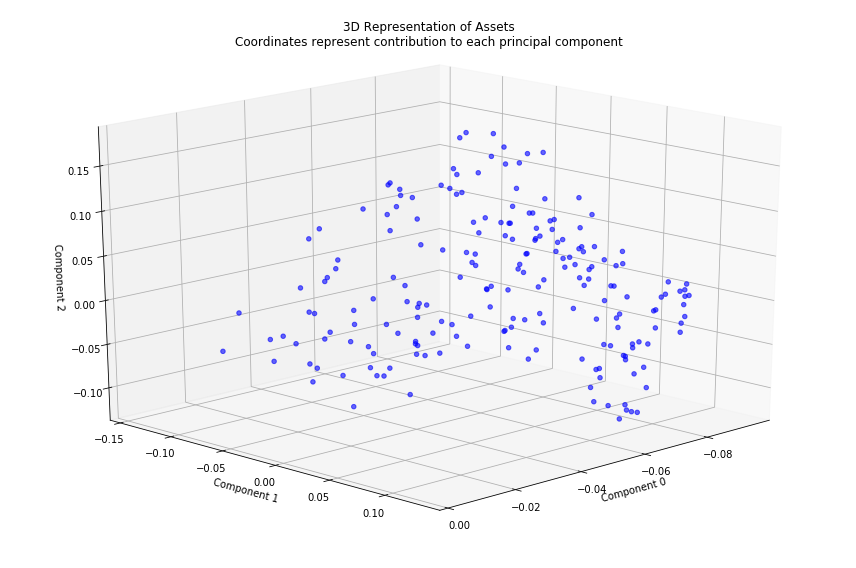

In [7]:
# 3D visualization of assets
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    factor_exposures['component_0'], 
    factor_exposures['component_1'], 
    factor_exposures['component_2'],
    c='blue', 
    marker='o', 
    s=20, 
    alpha=0.6
)

ax.set_xlabel('Component 0', fontsize=10)
ax.set_ylabel('Component 1', fontsize=10)
ax.set_zlabel('Component 2', fontsize=10)
ax.set_title('3D Representation of Assets\nCoordinates represent contribution to each principal component', 
             fontsize=12)
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

### Step 6: Apply OPTICS Clustering

Number of clusters: 7
Number of noisy samples: 114
Number of non-noisy samples: 86


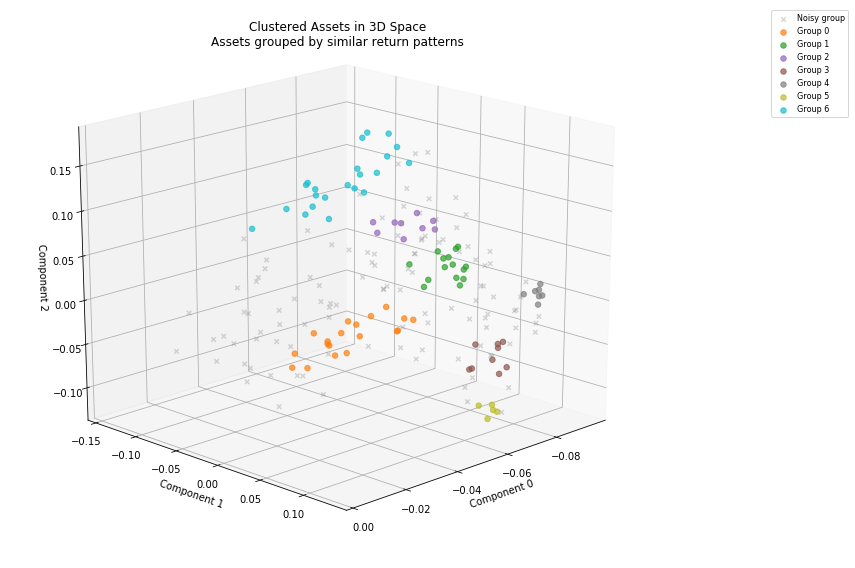


Cluster sizes:
Cluster 0: 19 assets
Cluster 1: 15 assets
Cluster 2: 9 assets
Cluster 3: 9 assets
Cluster 4: 7 assets
Cluster 5: 5 assets
Cluster 6: 22 assets


In [8]:
# Apply OPTICS clustering
clustering = OPTICS().fit(factor_exposures)

# Analyze clustering results
labels = clustering.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Number of clusters: {n_clusters}")
print(f"Number of noisy samples: {n_noise}")
print(f"Number of non-noisy samples: {len(labels) - n_noise}")

# Visualize clusters
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Define colors for different clusters
unique_labels = sorted(set(labels))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for idx, cluster_id in enumerate(unique_labels):
    cluster_mask = labels == cluster_id
    cluster_data = factor_exposures[cluster_mask]
    
    if cluster_id == -1:
        # Noisy samples in gray with lower alpha
        ax.scatter(
            cluster_data['component_0'],
            cluster_data['component_1'],
            cluster_data['component_2'],
            c='gray',
            marker='x',
            s=20,
            alpha=0.3,
            label='Noisy group'
        )
    else:
        ax.scatter(
            cluster_data['component_0'],
            cluster_data['component_1'],
            cluster_data['component_2'],
            c=[colors[idx]],
            marker='o',
            s=30,
            alpha=0.7,
            label=f'Group {cluster_id}'
        )

ax.set_xlabel('Component 0', fontsize=10)
ax.set_ylabel('Component 1', fontsize=10)
ax.set_zlabel('Component 2', fontsize=10)
ax.set_title('Clustered Assets in 3D Space\nAssets grouped by similar return patterns', 
             fontsize=12)
ax.view_init(elev=20, azim=45)
ax.legend(bbox_to_anchor=(1.15, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

# Print cluster sizes
print("\nCluster sizes:")
for cluster_id in sorted(set(labels)):
    if cluster_id >= 0:
        count = list(labels).count(cluster_id)
        print(f"Cluster {cluster_id}: {count} assets")

### Step 7: Pair Selection with Statistical Tests
Test all possible pairs within clusters using 4 criteria:
1. Cointegration test (p-value < 0.01)
2. Hurst exponent < 0.5 (mean-reverting)
3. Half-life between 1 and 252 days
4. At least 12 mean crossings per year

In [9]:
pairs_tested = 0
pairs_errored = 0
test_results_index = [
    'Failed at cointegration test',
    'Failed at Hurst test',
    'Failed at half-life test',
    'Failed at crossing the mean'
]
test_results = pd.DataFrame(
    {"count": [0] * len(test_results_index)},
    index=test_results_index
)
pairs_detected = []

# Only process non-noisy clusters
valid_labels = labels[labels != -1]
unique_clusters = sorted(set(valid_labels))

print(f"Testing pairs across {len(unique_clusters)} clusters...\n")

# Loop through each cluster
for cluster_id in unique_clusters:
    # Select all assets in this cluster
    cluster_symbols = list(
        factor_exposures.index[labels == cluster_id]
    )
    
    print(f"Cluster {cluster_id}: {len(cluster_symbols)} assets, testing {len(list(combinations(cluster_symbols, 2)))} pairs")
    
    # Loop through all possible pairs in the cluster
    for symbol_a, symbol_b in combinations(cluster_symbols, 2):
        pairs_tested += 1
        
        try:
            # Test 1: Cointegration using simplified test
            pvalue_ab, hedge_ab, spread_ab, intercept_ab = simple_cointegration_test(prices[symbol_a], prices[symbol_b])
            pvalue_ba, hedge_ba, spread_ba, intercept_ba = simple_cointegration_test(prices[symbol_b], prices[symbol_a])
            
            # Select the test with the lower p-value
            if pvalue_ab < pvalue_ba:
                pvalue = pvalue_ab
                spread = spread_ab
                hedge_ratio = hedge_ab
                dependent_var = symbol_a
                independent_var = symbol_b
            else:
                pvalue = pvalue_ba
                spread = spread_ba
                hedge_ratio = hedge_ba
                dependent_var = symbol_b
                independent_var = symbol_a
            
            # Check p-value
            if pvalue > 0.01:
                test_results.loc[test_results_index[0], 'count'] += 1
                continue
            
            # Test 2: Hurst exponent (mean-reverting)
            # kind='random_walk' treats the spread as a level series and works
            # with negative values. kind='price' computes percentage changes,
            # which blow up on a mean-zero spread that crosses zero.
            H, _, _ = compute_Hc(spread.values, kind='random_walk', simplified=False)
            if H >= 0.5:
                test_results.loc[test_results_index[1], 'count'] += 1
                continue
            
            # Test 3: Half-life (between 1 and 252 days)
            # AR(1) regression of spread changes on lagged spread, dropping the
            # first observation (np.roll would wrap the last value to the front
            # and inject an artificial data point)
            lagged_spread = spread.shift(1).iloc[1:]
            spread_delta = spread.diff().iloc[1:]
            
            model = OLS(spread_delta, add_constant(lagged_spread))
            beta = model.fit().params.iloc[1]
            
            # Check if beta is valid for mean reversion (should be negative)
            if beta >= 0:
                test_results.loc[test_results_index[2], 'count'] += 1
                continue
                
            half_life = -np.log(2) / beta
            
            if not (1 < half_life < 252):
                test_results.loc[test_results_index[2], 'count'] += 1
                continue
            
            # Test 4: Mean crossings (at least 12 per year)
            mean_value = spread.mean()
            crossings = (
                (spread > mean_value) & (spread.shift(1) <= mean_value) |
                (spread < mean_value) & (spread.shift(1) >= mean_value)
            )
            num_crossings = crossings.sum()
            years = len(spread) / 252
            crossings_per_year = num_crossings / years
            
            if crossings_per_year < 12:
                test_results.loc[test_results_index[3], 'count'] += 1
                continue
            
            # All tests passed!
            pairs_detected.append({
                'symbol_a': symbol_a,
                'symbol_b': symbol_b,
                'dependent': dependent_var,
                'independent': independent_var,
                'spread': spread,
                'hedge_ratio': hedge_ratio,
                'hurst': H,
                'half_life': half_life,
                'crossings_per_year': crossings_per_year,
                'p_value': pvalue,
                'cluster_id': cluster_id
            })
            
        except Exception as e:
            # Count errored pairs instead of hiding them completely
            pairs_errored += 1
            continue

# Calculate statistics
test_results['percent_of_tested'] = round(
    test_results['count'] / pairs_tested, 4
)
test_results['cumulative_percent_of_tested'] = \
    test_results['percent_of_tested'].cumsum()

print(f"\n{'='*60}")
print(f"PAIR SELECTION RESULTS")
print(f"{'='*60}")
print(f"Total pairs tested: {pairs_tested}")
print(f"Pairs skipped due to errors: {pairs_errored}")
print(f"Pairs detected: {len(pairs_detected)}\n")
print("Test results breakdown:")
print(test_results)

# Display detected pairs

if len(pairs_detected) > 0:
    pairs_df = pd.DataFrame(pairs_detected)[['dependent', 'independent', 'hurst', 'half_life', 'crossings_per_year', 'p_value', 'cluster_id']]
    print("\nDetected pairs (dependent = y, independent = x):")
    print(pairs_df)
else:
    print("\nNo pairs detected. Consider relaxing criteria or using a larger universe.")

Testing pairs across 7 clusters...

Cluster 0: 19 assets, testing 171 pairs
Cluster 1: 15 assets, testing 105 pairs
Cluster 2: 9 assets, testing 36 pairs
Cluster 3: 9 assets, testing 36 pairs
Cluster 4: 7 assets, testing 21 pairs
Cluster 5: 5 assets, testing 10 pairs
Cluster 6: 22 assets, testing 231 pairs

PAIR SELECTION RESULTS
Total pairs tested: 610
Pairs skipped due to errors: 0
Pairs detected: 56

Test results breakdown:
                              count  percent_of_tested  \
Failed at cointegration test    552             0.9049   
Failed at Hurst test              2             0.0033   
Failed at half-life test          0             0.0000   
Failed at crossing the mean       0             0.0000   

                              cumulative_percent_of_tested  
Failed at cointegration test                        0.9049  
Failed at Hurst test                                0.9082  
Failed at half-life test                            0.9082  
Failed at crossing the mean       

### Step 8: Visualize Detected Pairs

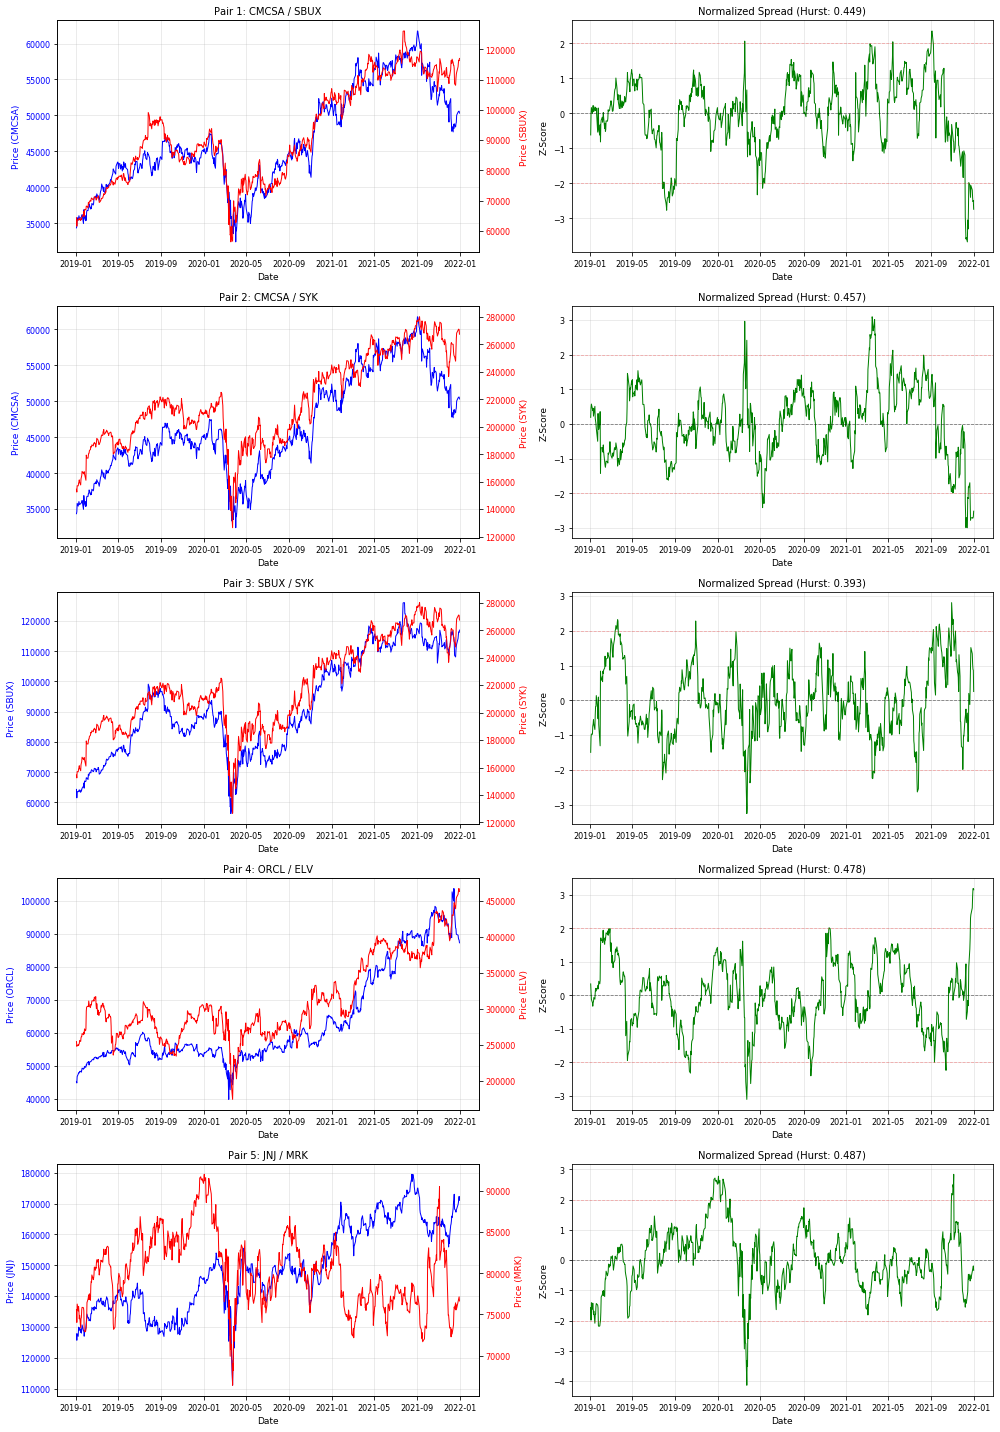

In [10]:
# Step 8: Visualize Detected Pairs
if len(pairs_detected) > 0:
    num_rows = min(len(pairs_detected), 5)  # Limit to 5 pairs for visualization
    
    fig, axes = plt.subplots(num_rows, 2, figsize=(14, 4*num_rows))
    
    # Handle case when only one pair is detected
    if num_rows == 1:
        axes = axes.reshape(1, -1)
    
    for i, pair in enumerate(pairs_detected[:num_rows]):
        symbol_a = pair['symbol_a']
        symbol_b = pair['symbol_b']
        price_a = prices[symbol_a]
        price_b = prices[symbol_b]
        
        # Left subplot: Prices of both stocks
        ax1 = axes[i, 0]
        ax1_twin = ax1.twinx()
        
        ax1.plot(price_a.index, price_a, 'b-', label=symbol_a, linewidth=1)
        ax1_twin.plot(price_b.index, price_b, 'r-', label=symbol_b, linewidth=1)
        
        ax1.set_xlabel('Date', fontsize=9)
        ax1.set_ylabel(f'Price ({symbol_a})', color='b', fontsize=9)
        ax1_twin.set_ylabel(f'Price ({symbol_b})', color='r', fontsize=9)
        ax1.tick_params(axis='y', labelcolor='b', labelsize=8)
        ax1_twin.tick_params(axis='y', labelcolor='r', labelsize=8)
        ax1.tick_params(axis='x', labelsize=8)
        ax1.set_title(f'Pair {i+1}: {symbol_a} / {symbol_b}', fontsize=10)
        ax1.grid(True, alpha=0.3)
        
        # Right subplot: Normalized spread (z-score)
        ax2 = axes[i, 1]
        normalized_spread = pd.Series(
            StandardScaler().fit_transform(
                pair['spread'].values.reshape(-1, 1)
            ).flatten(),
            index=pair['spread'].index
        )
        
        ax2.plot(normalized_spread.index, normalized_spread, 'g-', linewidth=1)
        ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5, linewidth=0.8)
        ax2.axhline(y=2, color='r', linestyle='--', alpha=0.3, linewidth=0.8)
        ax2.axhline(y=-2, color='r', linestyle='--', alpha=0.3, linewidth=0.8)
        
        ax2.set_xlabel('Date', fontsize=9)
        ax2.set_ylabel('Z-Score', fontsize=9)
        ax2.set_title(f'Normalized Spread (Hurst: {pair["hurst"]:.3f})', fontsize=10)
        ax2.tick_params(labelsize=8)
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No pairs to visualize")

### Step 9: Alternative - Single Pair Trading Strategy
Selects the best pair (lowest Hurst exponent), runs its out-of-sample backtest (2022-2024), and displays its results inline (total return + portfolio value plot)

Best pair: SYK / SBUX
Hurst exponent: 0.393
Half-life: 8.2 days
P-value: 0.0005
Crossings per year: 26.3

Running single-pair backtest...
Single-pair backtest completed!

Single-Pair Total Return: 0.00%


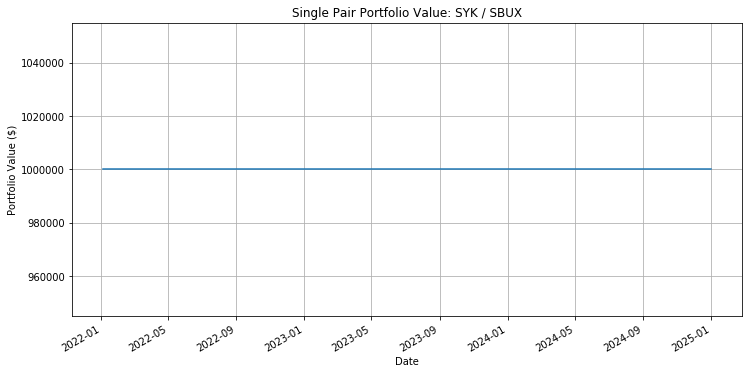

In [11]:
# Select the best pair (lowest Hurst exponent)
try:
    if 'pairs_detected' in dir() and len(pairs_detected) > 0:
        best_pair = sorted(pairs_detected, key=lambda x: x['hurst'])[0]
        
        print(f"Best pair: {best_pair['dependent']} / {best_pair['independent']}")
        print(f"Hurst exponent: {best_pair['hurst']:.3f}")
        print(f"Half-life: {best_pair['half_life']:.1f} days")
        print(f"P-value: {best_pair['p_value']:.4f}")
        print(f"Crossings per year: {best_pair['crossings_per_year']:.1f}")
        
        def initialize_single_pair(context):
            # Use the same orientation that passed the statistical tests:
            # dependent (y) regressed on independent (x)
            context.stock_x = symbol(best_pair['independent'])
            context.stock_y = symbol(best_pair['dependent'])
            context.rolling_window = 252
            context.z_threshold = 1.5
            context.z_exit = 0.5
            set_commission(PerTrade(cost=1))
        
        def handle_data_single_pair(context, data):
            try:
                if not (data.can_trade(context.stock_x) and data.can_trade(context.stock_y)):
                    return
                
                x_price = data.history(context.stock_x, "close", context.rolling_window, "1d")
                y_price = data.history(context.stock_y, "close", context.rolling_window, "1d")
                
                # Skip until both assets have a full price history (data.history
                # pulls pre-start data from the bundle, so no warm-up counter needed)
                if x_price.isnull().any() or y_price.isnull().any():
                    return
                
                x = np.log(x_price)
                y = np.log(y_price)
                
                _, p_value, _ = coint(x, y)
                if p_value > 0.05:
                    # Not cointegrated - exit all positions
                    order_target_percent(context.stock_x, 0)
                    order_target_percent(context.stock_y, 0)
                    return
                
                # add_constant(prepend=True) puts the constant FIRST, so the
                # params order is [intercept, slope]
                intercept, slope = sm.OLS(y, sm.add_constant(x, prepend=True)).fit().params
                
                # A non-positive slope inverts the long/short hedge - stand aside
                if slope <= 0:
                    order_target_percent(context.stock_x, 0)
                    order_target_percent(context.stock_y, 0)
                    return
                
                spread = y - (slope * x + intercept)
                zscore = (spread.iloc[-1] - spread.mean()) / spread.std()
                
                pos_x = context.portfolio.positions[context.stock_x].amount
                pos_y = context.portfolio.positions[context.stock_y].amount
                
                # Base weight for position sizing (50% of portfolio split between both sides)
                base_weight = 0.5
                
                # Trading logic with proper hedge ratio. The position checks
                # (pos_y >= 0 / pos_y <= 0) mean we only order on ENTRY instead
                # of re-targeting every bar while the signal persists.
                if abs(zscore) < context.z_exit:
                    # Exit positions when spread reverts to mean
                    if pos_x != 0 or pos_y != 0:
                        order_target_percent(context.stock_x, 0)
                        order_target_percent(context.stock_y, 0)
                
                elif zscore > context.z_threshold and pos_y >= 0:
                    # Spread too high: short y (overvalued), long x (undervalued)
                    # Hedge ratio maintains the pairs relationship: y = slope * x + intercept
                    order_target_percent(context.stock_y, -base_weight)
                    order_target_percent(context.stock_x, base_weight * slope)
                
                elif zscore < -context.z_threshold and pos_y <= 0:
                    # Spread too low: long y (undervalued), short x (overvalued)
                    order_target_percent(context.stock_y, base_weight)
                    order_target_percent(context.stock_x, -base_weight * slope)
            except Exception as e:
                # Surface errors instead of silently swallowing them
                print(f"handle_data error on {data.current_dt.date()}: {e}")
        
        # Run single pair backtest.
        # Out-of-sample: starts AFTER the formation window (2019-2021) used
        # for pair selection.
        print("\nRunning single-pair backtest...")
        
        single_results = run_algorithm(
            start=pd.to_datetime('2022-01-01', utc=True),
            end=pd.to_datetime('2024-12-31', utc=True),
            initialize=initialize_single_pair,
            handle_data=handle_data_single_pair,
            capital_base=1000000,
            data_frequency='daily',
            bundle='flounder-sharadar-sep',
            trading_calendar=get_calendar('XNYS')
        )
        
        print("Single-pair backtest completed!")
        
        # Display simple results
        print(f"\nSingle-Pair Total Return: {(single_results['portfolio_value'].iloc[-1] / single_results['portfolio_value'].iloc[0] - 1) * 100:.2f}%")
        
        # Plot portfolio value
        fig, ax = plt.subplots(figsize=(12, 6))
        single_results['portfolio_value'].plot(ax=ax)
        ax.set_title(f'Single Pair Portfolio Value: {best_pair["dependent"]} / {best_pair["independent"]}')
        ax.set_xlabel('Date')
        ax.set_ylabel('Portfolio Value ($)')
        ax.grid(True)
        plt.show()
    else:
        print("No pairs detected. Please run Step 7: Pair Selection with Statistical Tests first.")
except NameError:
    print("Please run Step 7: Pair Selection with Statistical Tests first to detect pairs.")

### Step 10: Select Top Pairs for Trading

In [12]:
# Select top pairs for trading (e.g., top 5 by Hurst exponent)
if len(pairs_detected) > 0:
    # Sort by Hurst exponent (lower is better for mean reversion)
    pairs_detected_sorted = sorted(pairs_detected, key=lambda x: x['hurst'])
    
    # Select top pairs, skipping any pair that shares a symbol with an
    # already-selected pair. order_target_percent sets an ABSOLUTE target per
    # asset, so two pairs trading the same symbol would overwrite each other's
    # positions and silently break both hedges.
    max_pairs = 5
    trading_pairs = []
    used_symbols = set()
    
    for pair in pairs_detected_sorted:
        if len(trading_pairs) >= max_pairs:
            break
        if pair['symbol_a'] in used_symbols or pair['symbol_b'] in used_symbols:
            continue
        trading_pairs.append(pair)
        used_symbols.update([pair['symbol_a'], pair['symbol_b']])
    
    print(f"Selected {len(trading_pairs)} pairs for trading (no shared symbols):")
    for i, pair in enumerate(trading_pairs, 1):
        print(f"{i}. {pair['dependent']} / {pair['independent']} - Hurst: {pair['hurst']:.3f}, Half-life: {pair['half_life']:.1f} days")
else:
    trading_pairs = []
    print("No pairs available for trading")

Selected 5 pairs for trading (no shared symbols):
1. SYK / SBUX - Hurst: 0.393, Half-life: 8.2 days
2. WMT / DG - Hurst: 0.416, Half-life: 10.8 days
3. MRK / GILD - Hurst: 0.434, Half-life: 12.4 days
4. BDX / D - Hurst: 0.443, Half-life: 12.6 days
5. ELV / ORCL - Hurst: 0.478, Half-life: 19.2 days


### Step 11: Define Zipline Multi-Pair Trading Strategy

In [13]:
# Define Zipline strategy for multi-pair trading
def initialize_multi_pair(context):
    """Initialize multi-pair trading strategy"""
    # Store trading pairs information, using the same orientation that passed
    # the statistical tests: dependent (y) regressed on independent (x)
    context.pairs = []
    
    for pair in trading_pairs:
        context.pairs.append({
            'stock_x': symbol(pair['independent']),
            'stock_y': symbol(pair['dependent']),
            'half_life': pair['half_life']
        })
    
    # Trading parameters
    context.rolling_window = 252  # 1 year
    context.z_threshold = 1.5  # Z-score threshold for entry
    context.z_exit = 0.5  # Z-score threshold for exit
    
    # Commission
    set_commission(PerTrade(cost=1))
    
    print(f"Initialized strategy with {len(context.pairs)} pairs")


def handle_data_multi_pair(context, data):
    """Handle data for multi-pair trading"""
    # Loop through all pairs
    for pair_info in context.pairs:
        stock_x = pair_info['stock_x']
        stock_y = pair_info['stock_y']
        
        try:
            # Check if both assets are tradeable
            if not (data.can_trade(stock_x) and data.can_trade(stock_y)):
                continue
            
            # Get price history
            x_price = data.history(stock_x, "close", context.rolling_window, "1d")
            y_price = data.history(stock_y, "close", context.rolling_window, "1d")
            
            # Skip until both assets have a full price history (data.history
            # pulls pre-start data from the bundle, so no warm-up counter needed)
            if x_price.isnull().any() or y_price.isnull().any():
                continue
            
            # Calculate log prices
            x = np.log(x_price)
            y = np.log(y_price)
            
            # Test cointegration
            _, p_value, _ = coint(x, y)
            if p_value > 0.05:  # Not cointegrated anymore
                # Exit positions if we have them
                order_target_percent(stock_x, 0)
                order_target_percent(stock_y, 0)
                continue
            
            # Calculate hedge ratio.
            # add_constant(prepend=True) puts the constant FIRST, so the
            # params order is [intercept, slope]
            intercept, slope = sm.OLS(y, sm.add_constant(x, prepend=True)).fit().params
            
            # A non-positive slope inverts the long/short hedge - stand aside
            if slope <= 0:
                order_target_percent(stock_x, 0)
                order_target_percent(stock_y, 0)
                continue
            
            # Calculate spread and z-score
            spread = y - (slope * x + intercept)
            zscore = (spread.iloc[-1] - spread.mean()) / spread.std()
            
            # Get current positions
            pos_x = context.portfolio.positions[stock_x].amount
            pos_y = context.portfolio.positions[stock_y].amount
            
            # Capital allocation per pair (50% total portfolio divided among pairs)
            base_weight = 0.5 / len(context.pairs)
            
            # Trading logic with proper hedge ratio. The position checks
            # (pos_y >= 0 / pos_y <= 0) mean we only order on ENTRY instead of
            # re-targeting every bar while the signal persists.
            if abs(zscore) < context.z_exit:
                # Close positions if z-score reverts to mean
                if pos_x != 0 or pos_y != 0:
                    order_target_percent(stock_x, 0)
                    order_target_percent(stock_y, 0)
            
            elif zscore > context.z_threshold and pos_y >= 0:
                # Spread too high: short y (overvalued), long x (undervalued)
                # Hedge ratio maintains the pairs relationship: y = slope * x + intercept
                order_target_percent(stock_y, -base_weight)
                order_target_percent(stock_x, base_weight * slope)
            
            elif zscore < -context.z_threshold and pos_y <= 0:
                # Spread too low: long y (undervalued), short x (overvalued)
                order_target_percent(stock_y, base_weight)
                order_target_percent(stock_x, -base_weight * slope)
        
        except Exception as e:
            # Surface errors instead of silently swallowing them
            print(f"handle_data error for {stock_y.symbol}/{stock_x.symbol} on {data.current_dt.date()}: {e}")
            continue

print("Strategy functions defined successfully")

Strategy functions defined successfully


### Step 12: Run Multi-Pair Backtest

In [14]:
# Check if previous steps have been completed
try:
    if 'trading_pairs' in dir() and len(trading_pairs) > 0:
        # Backtest period starts AFTER the pair-selection (formation) window
        # (2019-2021), so the backtest is genuinely out-of-sample
        backtest_start_date = pd.to_datetime('2022-01-01', utc=True)
        backtest_end_date = pd.to_datetime('2024-12-31', utc=True)
        
        print(f"Running backtest from {backtest_start_date.date()} to {backtest_end_date.date()}...\n")
        
        results = run_algorithm(
            start=backtest_start_date,
            end=backtest_end_date,
            initialize=initialize_multi_pair,
            handle_data=handle_data_multi_pair,
            capital_base=1000000,
            data_frequency='daily',
            bundle='flounder-sharadar-sep',
            trading_calendar=get_calendar('XNYS')
        )
        
        print("\nBacktest completed successfully!")
    else:
        print("Cannot run backtest: No pairs detected or trading_pairs not defined")
        print("Please run previous cells:")
        print("- Step 9: Select Top Pairs for Trading")
        print("- Step 10: Define Zipline Multi-Pair Trading Strategy")
except NameError:
    print("Please run the previous cells first:")
    print("- Step 7: Pair Selection with Statistical Tests")
    print("- Step 9: Select Top Pairs for Trading")
    print("- Step 10: Define Zipline Multi-Pair Trading Strategy")

Running backtest from 2022-01-01 to 2024-12-31...

Initialized strategy with 5 pairs

Backtest completed successfully!


### Step 13: Display Multi-Pair Backtest Results
Total return, Sharpe ratio, max drawdown, transactions, and portfolio value / cumulative return charts for the multi-pair backtest


BACKTEST SUMMARY
Total Return: 1.03%
Sharpe Ratio: 0.71
Max Drawdown: -0.30%
Total Transactions: 753

Sample Transactions:


,transactions
2022-01-03 21:00:00+00:00,[]
2022-01-04 21:00:00+00:00,[]
2022-01-05 21:00:00+00:00,[]
2022-01-06 21:00:00+00:00,[]
2022-01-07 21:00:00+00:00,[]
2022-01-10 21:00:00+00:00,[]
2022-01-11 21:00:00+00:00,[]
2022-01-12 21:00:00+00:00,[]
2022-01-13 21:00:00+00:00,[]
2022-01-14 21:00:00+00:00,[]


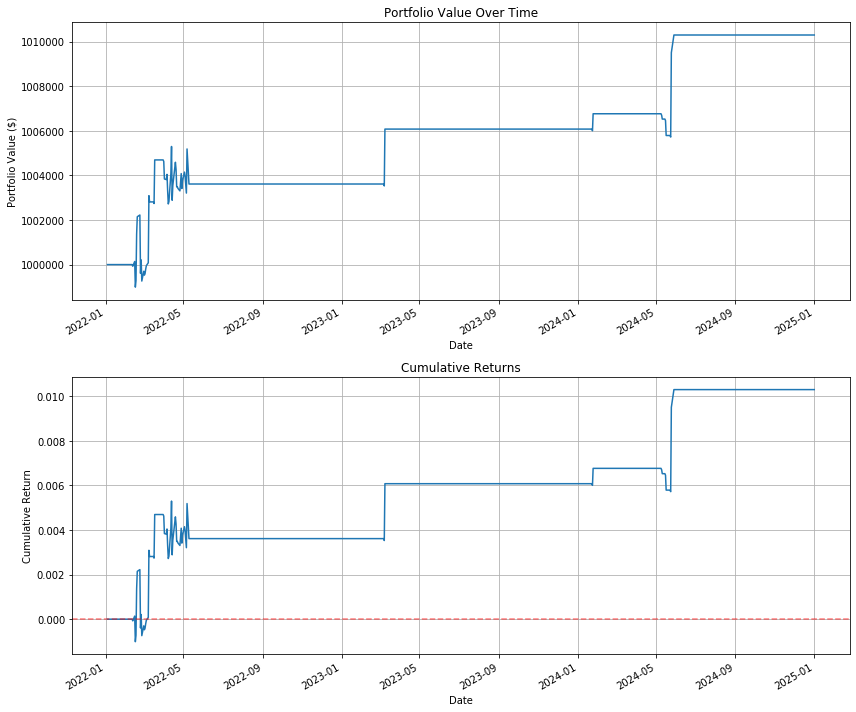

In [15]:
# Check if backtest has been run
try:
    if 'trading_pairs' in dir() and 'results' in dir() and len(trading_pairs) > 0:
        print("\n" + "="*60)
        print("BACKTEST SUMMARY")
        print("="*60)
        print(f"Total Return: {(results['portfolio_value'].iloc[-1] / results['portfolio_value'].iloc[0] - 1) * 100:.2f}%")
        
        # Calculate Sharpe Ratio
        returns = results['returns']
        sharpe = returns.mean() / returns.std() * np.sqrt(252)
        print(f"Sharpe Ratio: {sharpe:.2f}")
        
        # Calculate Max Drawdown
        cumulative = (1 + returns).cumprod()
        running_max = cumulative.cummax()
        drawdown = (cumulative - running_max) / running_max
        max_drawdown = drawdown.min()
        print(f"Max Drawdown: {max_drawdown * 100:.2f}%")
        
        # Display transactions count
        if hasattr(results, 'transactions') and results.transactions is not None:
            print(f"Total Transactions: {len(results.transactions)}")
            
            # Display sample transactions
            print("\nSample Transactions:")
            display(pd.DataFrame(results.transactions[:20]))
        
        # Plot portfolio value
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
        
        # Portfolio value
        results['portfolio_value'].plot(ax=ax1)
        ax1.set_title('Portfolio Value Over Time')
        ax1.set_xlabel('Date')
        ax1.set_ylabel('Portfolio Value ($)')
        ax1.grid(True)
        
        # Cumulative returns
        cumulative_returns = (1 + returns).cumprod() - 1
        cumulative_returns.plot(ax=ax2)
        ax2.set_title('Cumulative Returns')
        ax2.set_xlabel('Date')
        ax2.set_ylabel('Cumulative Return')
        ax2.grid(True)
        ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        plt.show()
    else:
        print("Please run the previous cells first:")
        print("- Step 9: Select Top Pairs for Trading")
        print("- Step 10: Define Zipline Multi-Pair Trading Strategy")
        print("- Step 11: Run Backtest")
except NameError:
    print("Please run the previous cells first:")
    print("- Step 9: Select Top Pairs for Trading")
    print("- Step 10: Define Zipline Multi-Pair Trading Strategy")
    print("- Step 11: Run Backtest")

### Step 14: Pyfolio Performance Analysis (benchmarked vs BIL)
Full pyfolio tear sheet for the multi-pair backtest: annualized return/volatility, Sharpe/Sortino/Calmar, drawdown periods, rolling metrics, monthly returns heatmap, exposure and turnover analysis.

The benchmark is **BIL (SPDR 1-3 Month T-Bill ETF)** from the Sharadar Fund Prices (SFP) bundle (`fsharadar.sfp`) - cash is the appropriate hurdle for a market-neutral strategy. With a cash benchmark, ignore the "beta" row (cash has ~zero variance); "alpha" approximates the annualized excess return over cash, which is the key figure. Change `BENCHMARK_SYMBOL` in the cell below to compare against another ETF (e.g. `'SPY'` for a market-beta reference, `'QAI'` for a hedge-fund-style peer).

Returns: 2022-01-03 to 2024-12-31
Days with position data: 48
Total transactions: 36

BIL benchmark: 2022-01-03 to 2024-12-31 (753 daily returns, cumulative 11.95%)



Start date,2022-01-03
End date,2024-12-31
Total months,35
,Backtest
Annual return,0.3%
Cumulative returns,1.0%
Annual volatility,0.5%
Sharpe ratio,0.71
Calmar ratio,1.16
Stability,0.86
Max drawdown,-0.3%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,0.30,2022-02-22,2022-02-25,2022-03-08,11
1,0.24,2022-04-12,2022-04-13,2023-03-08,237
2,0.20,2022-03-30,2022-04-07,2022-04-12,10
3,0.11,2022-02-14,2022-02-15,2022-02-17,4
4,0.10,2024-05-08,2024-05-23,2024-05-24,13


Stress Events,mean,min,max
New Normal,0.00%,-0.26%,0.38%


Top 10 long positions of all time,max
sid,
GILD,6.66%
D,4.65%
DG,4.56%
ORCL,3.55%


Top 10 short positions of all time,max
sid,
WMT,-10.52%
BDX,-10.13%
ELV,-10.09%
MRK,-10.03%


Top 10 positions of all time,max
sid,
WMT,10.52%
BDX,10.13%
ELV,10.09%
MRK,10.03%
GILD,6.66%
D,4.65%
DG,4.56%
ORCL,3.55%


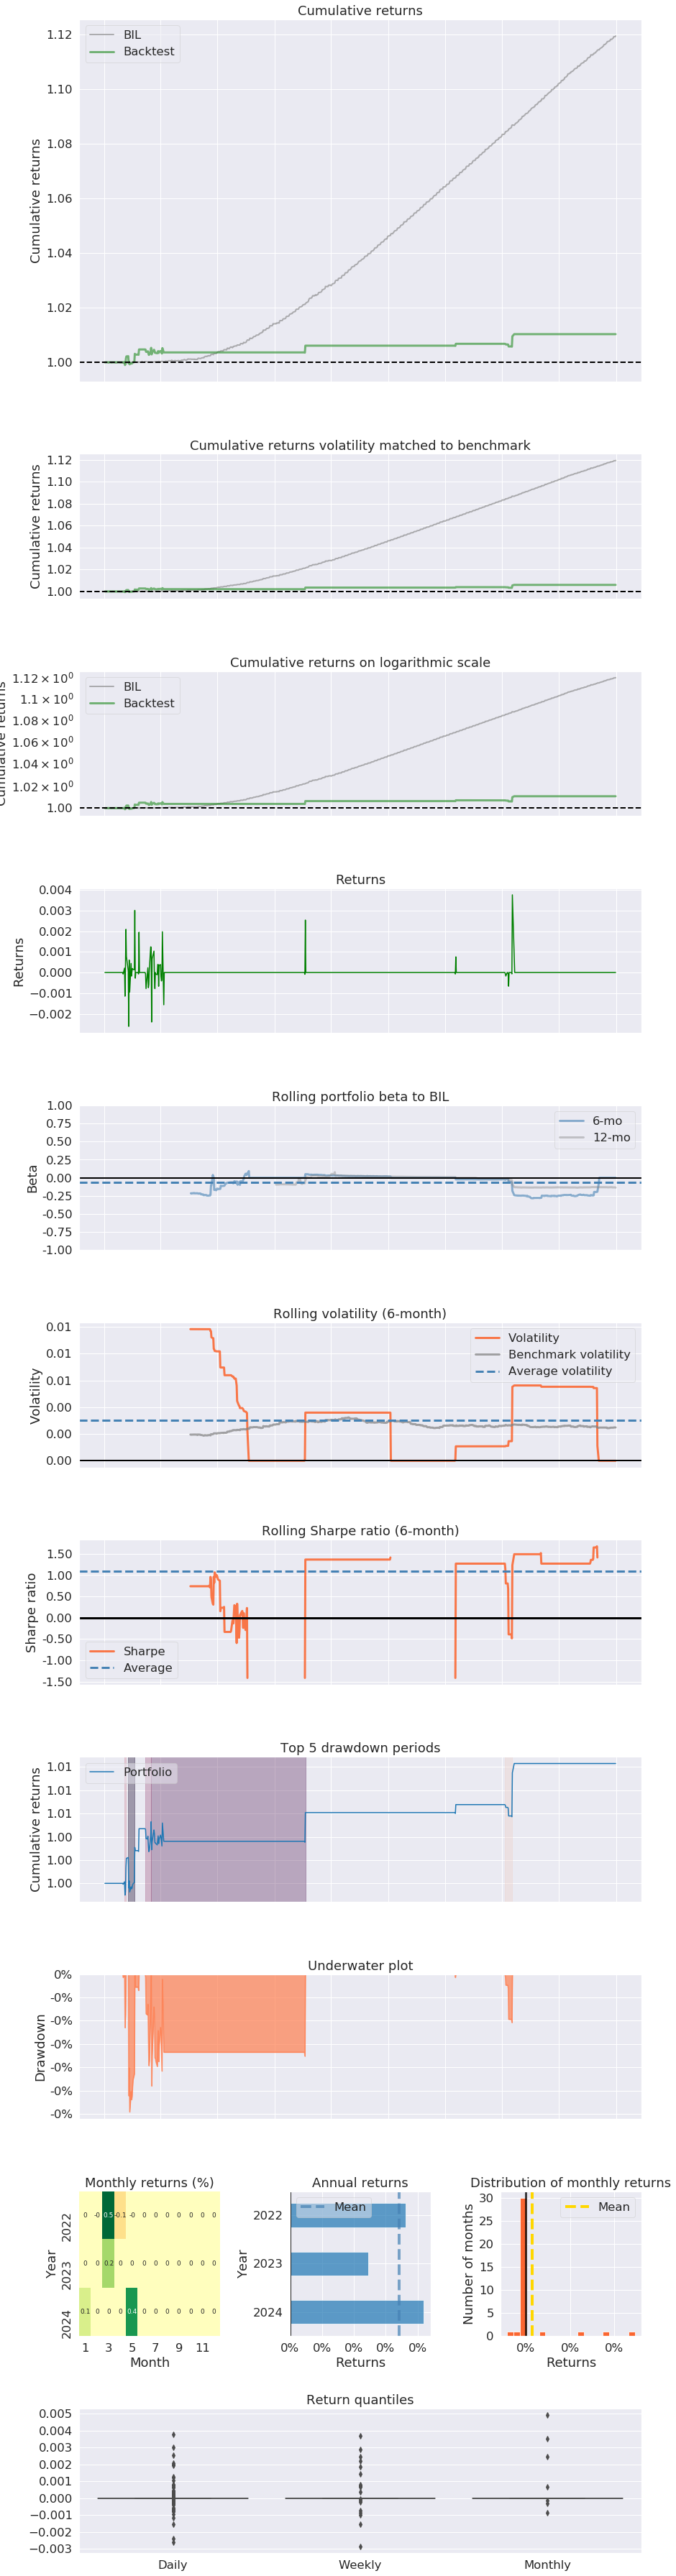

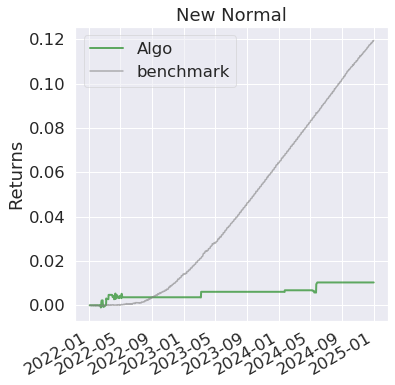

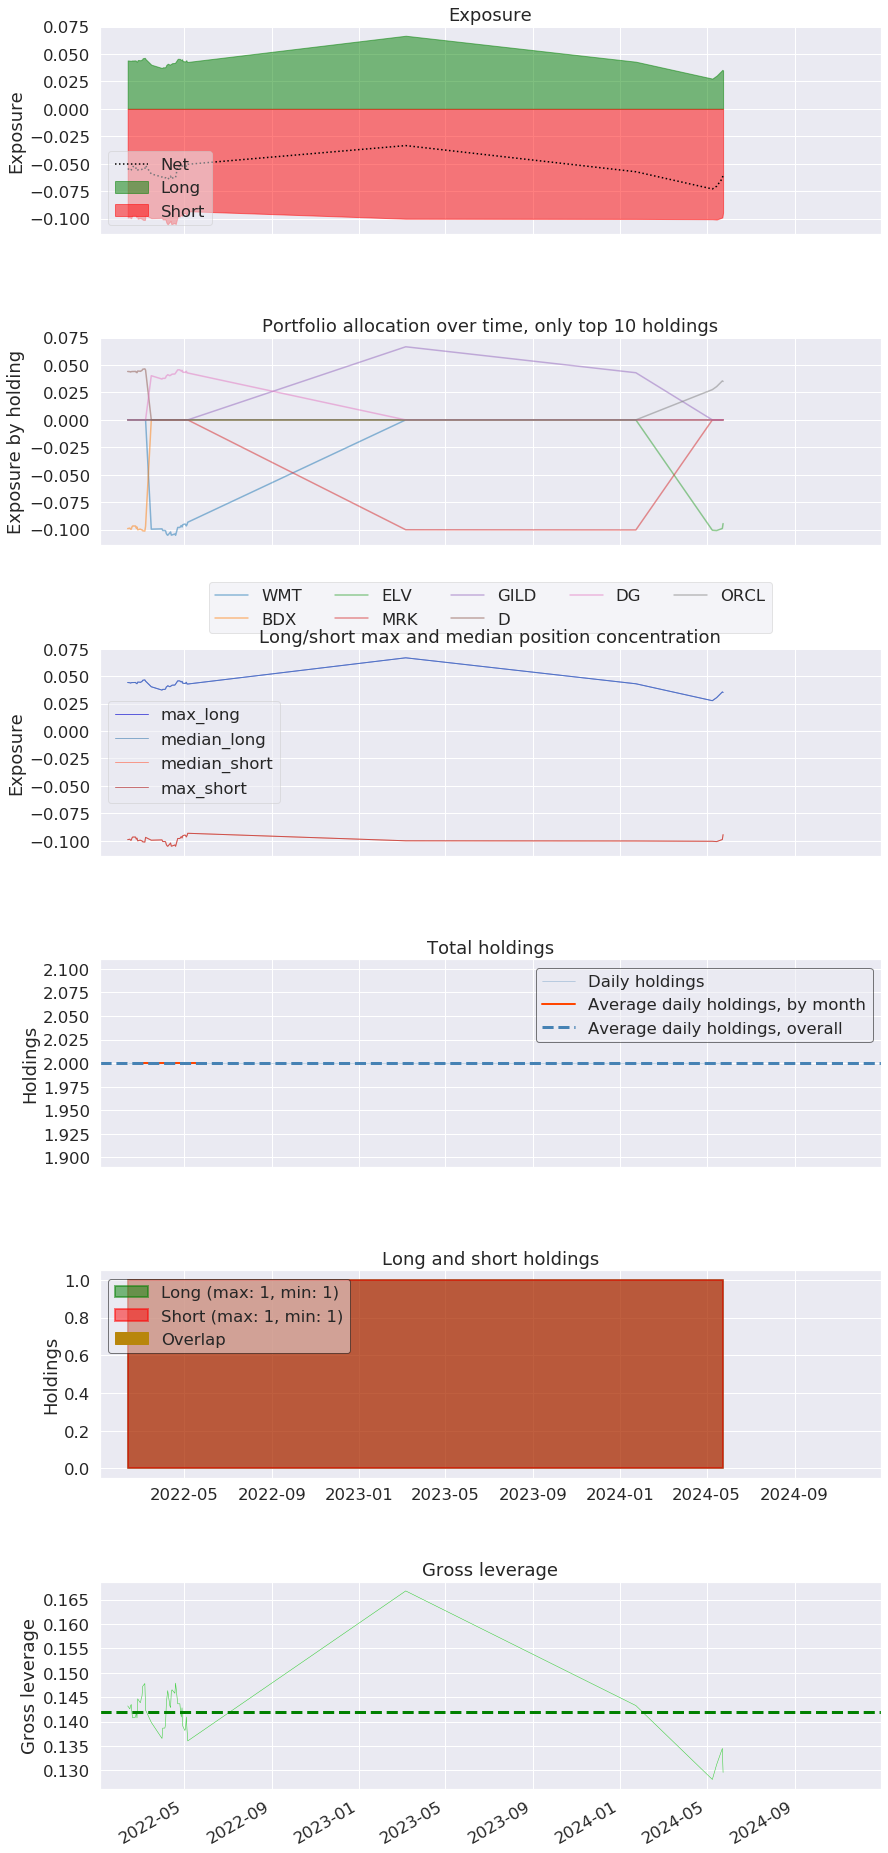

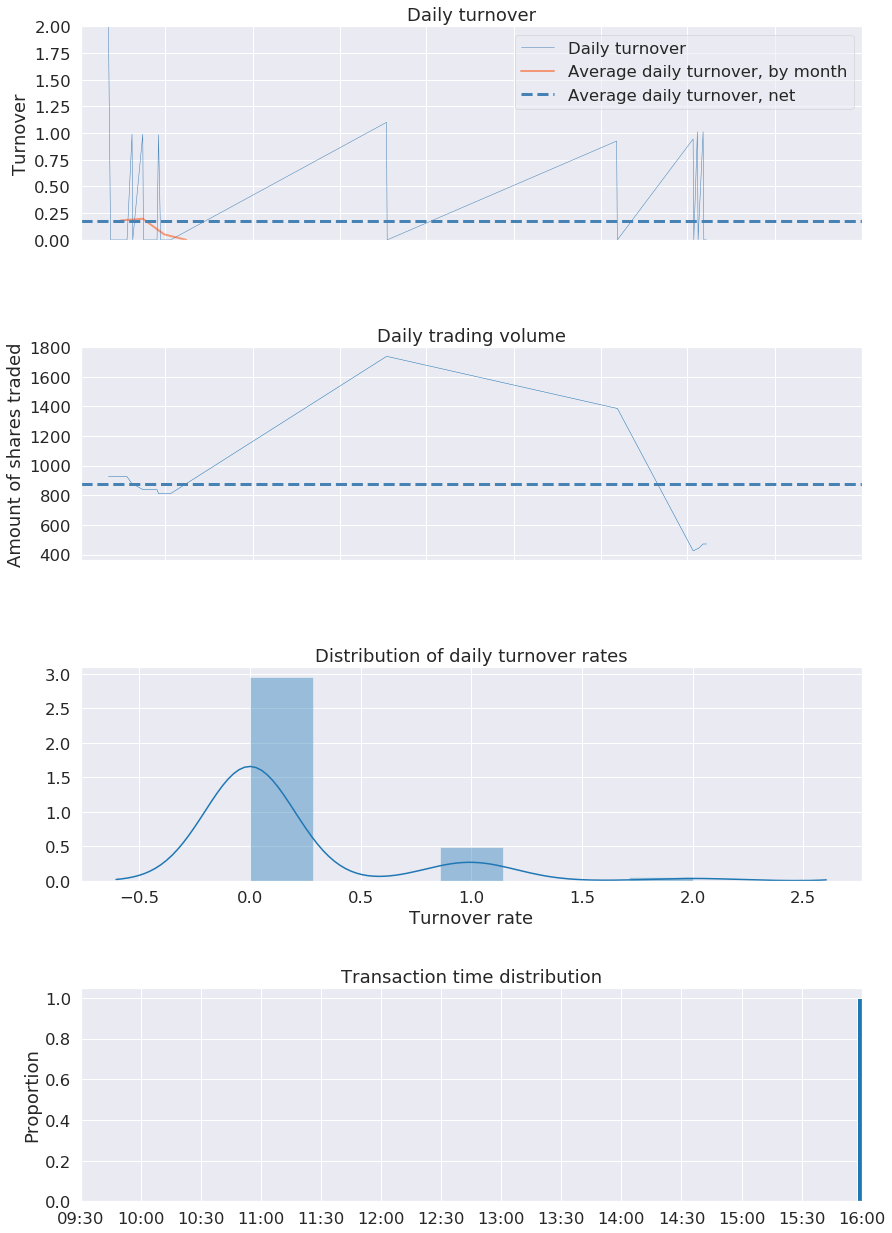

In [18]:
# Pyfolio tear sheet for the MULTI-PAIR backtest, benchmarked against BIL
# (SPDR 1-3 Month T-Bill ETF) from the Sharadar Fund Prices (SFP) bundle.
# Cash is the appropriate hurdle for a market-neutral strategy; note that with
# a cash benchmark, pyfolio's "beta" is meaningless but "alpha" is roughly the
# annualized excess return over cash - the number that matters here.
# (to analyze the single-pair backtest instead, replace `results` with `single_results`)
from fsharadar import sfp
from zipline.data.data_portal import DataPortal

BENCHMARK_SYMBOL = 'BIL'
benchmark_rets = None

try:
    if 'results' not in dir():
        raise RuntimeError("Please run Step 12 (Run Multi-Pair Backtest) first.")

    # Extract returns, positions and transactions from the zipline result frame
    pf_returns, pf_positions, pf_transactions = \
        pf.utils.extract_rets_pos_txn_from_zipline(results)

    print(f"Returns: {pf_returns.index[0].date()} to {pf_returns.index[-1].date()}")
    print(f"Days with position data: {len(pf_positions)}")
    print(f"Total transactions: {len(pf_transactions)}\n")

    # --- Build benchmark returns from the SFP bundle ---
    try:
        sfp_bundle = sfp.load()

        sfp_portal = DataPortal(
            sfp_bundle.asset_finder,
            trading_calendar=get_calendar('XNYS'),
            first_trading_day=sfp_bundle.equity_daily_bar_reader.first_trading_day,
            equity_daily_reader=sfp_bundle.equity_daily_bar_reader,
            adjustment_reader=sfp_bundle.adjustment_reader,
        )

        bench_asset = sfp_bundle.asset_finder.lookup_symbol(BENCHMARK_SYMBOL, as_of_date=None)

        # Sessions covering the backtest period, plus one extra bar before the
        # start so pct_change() yields a return for the first backtest day
        sfp_sessions = sfp_bundle.equity_daily_bar_reader.sessions
        bt_sessions = sfp_sessions[
            (sfp_sessions >= pf_returns.index[0].normalize()) &
            (sfp_sessions <= pf_returns.index[-1].normalize())
        ]

        bench_closes = sfp_portal.get_history_window(
            [bench_asset],
            bt_sessions[-1],
            len(bt_sessions) + 1,
            '1d',
            'close',
            'daily',
        )[bench_asset]

        benchmark_rets = bench_closes.pct_change().dropna().rename(BENCHMARK_SYMBOL)
        cum_bench = (1 + benchmark_rets).prod() - 1
        print(f"{BENCHMARK_SYMBOL} benchmark: {benchmark_rets.index[0].date()} to "
              f"{benchmark_rets.index[-1].date()} "
              f"({len(benchmark_rets)} daily returns, "
              f"cumulative {cum_bench * 100:.2f}%)\n")
    except Exception as e:
        print(f"Could not build {BENCHMARK_SYMBOL} benchmark from SFP bundle ({e}); "
              f"continuing without benchmark\n")
        benchmark_rets = None

    # Full tear sheet: performance stats, drawdowns, rolling Sharpe,
    # monthly returns heatmap, exposure, turnover, etc.
    try:
        pf.create_full_tear_sheet(
            pf_returns,
            positions=pf_positions,
            transactions=pf_transactions,
            benchmark_rets=benchmark_rets,
            round_trips=False
        )
    except Exception as e:
        # Some pyfolio versions choke on the positions/transactions analysis;
        # fall back to the returns-only tear sheet so we still get core stats
        print(f"Full tear sheet failed ({e}); falling back to returns-only tear sheet\n")
        pf.create_returns_tear_sheet(pf_returns, benchmark_rets=benchmark_rets)

except RuntimeError as e:
    print(e)

In [27]:

round_trips = pf.round_trips.extract_round_trips(
    pf_transactions[["amount", "price", "symbol"]]
)

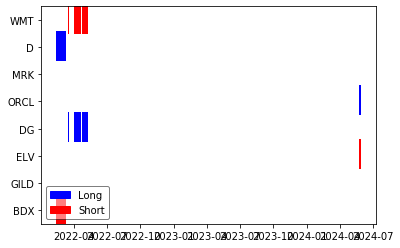

In [26]:
pf.plotting.plot_round_trip_lifetimes(round_trips,disp_amount=14, lsize=30)